# RNN 시계열 예측 — Sine Wave

노이즈가 섞인 사인파(sine wave) 시계열 데이터를 SimpleRNN으로 학습시켜, 다음 값을 예측하는 노트북입니다.

- **Dataset**: `np.sin(0.02*t) + noise`로 직접 생성한 1000개 길이의 인공 시계열 (train 800 / test 200)
- **모델**: `SimpleRNN(20)` → `Dense(1)`
- **다루는 내용**: 슬라이딩 윈도우(step) 방식으로 시계열을 지도학습 형태(X, Y)로 변환, SimpleRNN 학습, 예측 결과를 실제 시계열에 겹쳐서 시각화

> 아래 학습 로그(200 epoch)와 그래프는 실제로 학습을 돌려서 나온 결과를 그대로 담았습니다.


## 1. 데이터 전처리 함수 및 설정

`convertToMatrix`는 1차원 시계열을 "과거 `step`개 값을 보고 다음 값을 예측"하는 지도학습 형태로 바꿔주는 함수다.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN


def convertToMatrix(data, step):
    """1차원 시계열 data를 (step개 과거값 -> 다음 값) 형태의 지도학습용 (X, Y)로 변환한다.
    예: step=4 -> X[0]=[data[0..3]], Y[0]=data[4] / X[1]=[data[1..4]], Y[1]=data[5] ..."""
    X, Y = [], []
    for i in range(len(data) - step):
        d = i + step
        X.append(data[i:d, ])
        Y.append(data[d], )
    return np.array(X), np.array(Y)


step = 4      # 몇 개의 과거 값을 보고 다음 값을 예측할지
N = 1000      # 전체 시계열 길이
Tp = 800      # train 800개, test 200개


## 2. 시계열 데이터 생성
사인파에 랜덤 노이즈를 더해서 인공 시계열을 만들고 시각화한다.

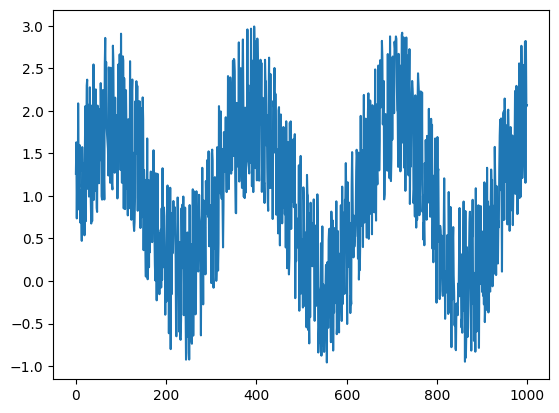

In [7]:
# 사인파에 약간의 노이즈를 섞은 시계열 데이터 생성
t = np.arange(0, N)
x = np.sin(0.02 * t) + 2 * np.random.rand(N)
df = pd.DataFrame(x)
df.head()

plt.plot(df)
plt.show()


## 3. Train/Test 분할 및 슬라이딩 윈도우 적용

In [8]:
train, test = df.values[0:Tp, :], df.values[Tp:N, :]  # train 800개, test 200개
print(train.shape)

# 슬라이딩 윈도우로 자를 때 마지막 구간이 짧아지지 않도록, 끝 값을 몇 개 복제해서 뒤에 붙여준다.
test = np.append(test, np.repeat(test[-1], step))

train = np.append(train, np.repeat(train[-1], step))

trainX, trainY = convertToMatrix(train, step)
testX, testY = convertToMatrix(test, step)

# SimpleRNN 입력 형태 (samples, timesteps, features)에 맞게 reshape
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))


(800, 1)


## 4. SimpleRNN 모델 학습
`step=4`개의 과거 값을 입력으로 받아 다음 값을 예측하는 회귀 문제로 200 epoch 학습시킨다.

In [9]:
model = Sequential()
model.add(SimpleRNN(20, return_sequences=False, input_shape=(1, 4)))
model.add(Dense(1))
model.summary()

model.compile(loss='mse', optimizer='adam', metrics=['accuracy'])
model.fit(trainX, trainY, epochs=200, verbose=2)

y_pred = model.predict(testX)


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_1 (SimpleRNN)    (None, 20)                500       
                                                                 
 dense_1 (Dense)             (None, 1)                 21        
                                                                 
Total params: 521 (2.04 KB)
Trainable params: 521 (2.04 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/200
25/25 - 2s - loss: 4.0238 - accuracy: 0.0000e+00 - 2s/epoch - 89ms/step
Epoch 2/200
25/25 - 0s - loss: 2.1765 - accuracy: 0.0000e+00 - 62ms/epoch - 2ms/step
Epoch 3/200
25/25 - 0s - loss: 1.1494 - accuracy: 0.0000e+00 - 69ms/epoch - 3ms/step
Epoch 4/200
25/25 - 0s - loss: 0.7178 - accuracy: 0.0000e+00 - 67ms/epoch - 3ms/step
Epoch 5/200
25/25 - 0s - loss: 0.5855 - accuracy: 0.0000e+00 - 62ms/epoch - 2ms/s

## 5. 예측 결과 시각화
테스트 구간에 대한 예측값을 실제 시계열 위에 겹쳐 그려서 얼마나 잘 따라가는지 눈으로 확인한다.

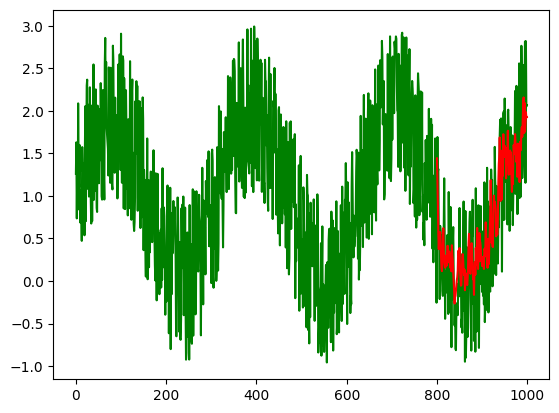

In [10]:
# 예측값을 원래 시계열 뒤쪽(테스트 구간)에 이어붙여서 실제 값과 겹쳐 그린다.
df_y_pred = pd.DataFrame(y_pred)
df_y_pred.index = df_y_pred.index + 800  # 테스트 구간 시작 인덱스(800)에 맞춰 정렬

plt.plot(df, color='g')          # 실제 시계열 (초록)
plt.plot(df_y_pred, color='r')   # 예측값 (빨강)
plt.show()


## 결과 및 배운 점

- loss(MSE)가 학습 초반 2.23에서 200 epoch 후 0.386까지 꾸준히 감소했고, 예측 곡선이 사인파의 대략적인 주기와
  진폭을 따라가는 것을 그래프로 확인할 수 있었다 (노이즈가 섞여 있어 완벽히 일치하지는 않는다).
- RNN을 쓰려면 시계열을 그냥 넣을 수 없고, `step` 크기만큼 잘라 (과거 값들 → 다음 값) 형태의 지도학습 데이터로 먼저 바꿔줘야 한다는 점, 그리고 `SimpleRNN`이 기대하는 입력 형태가 `(samples, timesteps, features)` 3차원이라 `reshape`가 필요하다는 점을 직접 다뤄보며 익혔다.
